## OgunBiome Differential Abundance Analysis

Identification of statistically significant microbial responders to 
chicory-derived inulin supplementation. Volcano plot production for 
the OgunBiome client report.

**Statistical basis:** Pre-calculated fold changes and Benjamini-Hochberg 
adjusted p-values from Baxter et al. 2019. Significance threshold: FDR < 0.05.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import yaml
import os

In [3]:
#Set working directory
os.chdir("/mnt/c/Users/oluwa/Desktop/MayTech/OgunBiome")
print(f"Working directory: {os.getcwd()}")

Working directory: /mnt/c/Users/oluwa/Desktop/MayTech/OgunBiome


In [5]:
#Load data
with open("config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

df = pd.read_csv("results/diversity/genus_abundance_summary.csv")

print(f"Genera loaded: {df.shape[0]}")
df

Genera loaded: 13


,Classification,abund_before,abund_during,fold_change,adjusted_pvalue
0,Acidaminococcus,0.149263,0.324376,2.173186,0.742649
1,Akkermansia,0.456859,0.617460,1.351532,0.783971
2,Anaerostipes,0.943367,2.013549,2.162921,0.000130
3,Bacteroides,1.293197,1.557200,1.436247,0.742649
4,Bifidobacterium,1.352381,4.254762,3.540065,0.002175
5,Escherichia/Shigella,0.389002,0.415590,1.068347,0.742649
6,Faecalibacterium,2.360488,3.218141,1.481193,0.742649
7,Lachnospiraceae,0.178912,0.208560,1.165716,0.742649
8,Megasphaera,0.060204,0.209354,3.477401,0.742649
9,Oscillibacter,0.052494,0.087982,1.683941,0.266610


## 1. Calculate Volcano Plot Coordinates

In [6]:
df["log2_fc"] = np.log2(df["fold_change"])
df["neg_log10_p"] = -np.log10(df["adjusted_pvalue"])

print("Volcano coordinates calculated:")
df[["Classification", "log2_fc", "neg_log10_p", "adjusted_pvalue"]]

Volcano coordinates calculated:


,Classification,log2_fc,neg_log10_p,adjusted_pvalue
0,Acidaminococcus,1.119812,0.129216,0.742649
1,Akkermansia,0.434596,0.105700,0.783971
2,Anaerostipes,1.112981,3.886580,0.000130
3,Bacteroides,0.522304,0.129216,0.742649
4,Bifidobacterium,1.823776,2.662441,0.002175
5,Escherichia/Shigella,0.095381,0.129216,0.742649
6,Faecalibacterium,0.566760,0.129216,0.742649
7,Lachnospiraceae,0.221216,0.129216,0.742649
8,Megasphaera,1.798009,0.129216,0.742649
9,Oscillibacter,0.751842,0.574124,0.266610


## 2. Volcano Plot

Each point represents one genus. Horizontal axis shows log2 fold change 
during inulin supplementation. Vertical axis shows statistical significance 
as -log10 adjusted p-value. Dashed line marks FDR = 0.05 threshold.
Significant genera labelled explicitly.

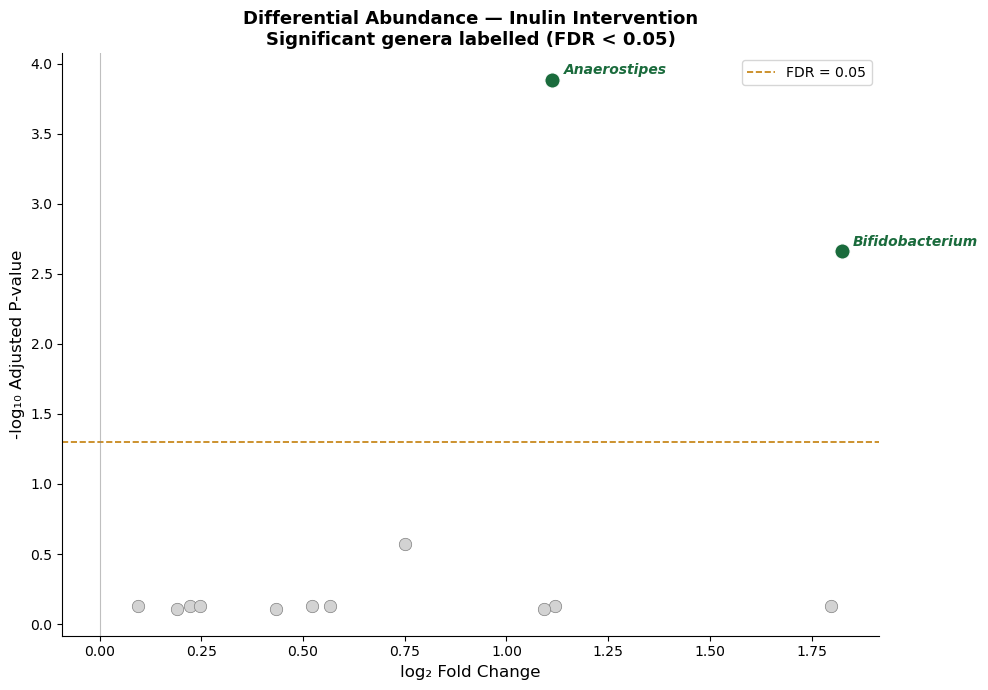

Saved: results/differential_abundance/volcano_plot.png


In [7]:
green = config["report"]["colors"]["green"]
gold = config["report"]["colors"]["gold"]
fdr_threshold = -np.log10(config["thresholds"]["fdr"])
highlight = config["highlight_taxa"]

fig, ax = plt.subplots(figsize=(10, 7))

# Plot all genera as grey points first
ax.scatter(df["log2_fc"], df["neg_log10_p"],
           color="lightgrey", s=80, zorder=2, edgecolors="grey",
           linewidths=0.5)

# Overlay significant genera in green
significant = df[df["adjusted_pvalue"] < config["thresholds"]["fdr"]]
ax.scatter(significant["log2_fc"], significant["neg_log10_p"],
           color=green, s=120, zorder=3, edgecolors="white",
           linewidths=0.8)

# Label significant genera
for _, row in significant.iterrows():
    ax.annotate(
        row["Classification"],
        xy=(row["log2_fc"], row["neg_log10_p"]),
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=10, fontstyle="italic",
        fontweight="bold", color=green
    )

# Significance threshold line
ax.axhline(y=fdr_threshold, color=gold, linestyle="--",
           linewidth=1.2, label=f"FDR = 0.05")

# Fold change reference line
ax.axvline(x=0, color="grey", linestyle="-",
           linewidth=0.8, alpha=0.5)

ax.set_xlabel("log₂ Fold Change", fontsize=12)
ax.set_ylabel("-log₁₀ Adjusted P-value", fontsize=12)
ax.set_title(
    "Differential Abundance — Inulin Intervention\n"
    "Significant genera labelled (FDR < 0.05)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("results/differential_abundance/volcano_plot.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/differential_abundance/volcano_plot.png")

## 3. Significant Results Table

In [8]:
significant_results = df[
    df["adjusted_pvalue"] < config["thresholds"]["fdr"]
].copy()

significant_results.to_csv(
    "results/differential_abundance/significant_results.csv",
    index=False
)

print("Significant genera:")
significant_results[["Classification", "fold_change", 
                      "log2_fc", "adjusted_pvalue"]]

Significant genera:


,Classification,fold_change,log2_fc,adjusted_pvalue
2,Anaerostipes,2.162921,1.112981,0.000130
4,Bifidobacterium,3.540065,1.823776,0.002175


## Summary — Step 3 Differential Abundance

### What Was Done
Volcano plot produced from genus-level abundance data. Log2 fold change 
and -log10 adjusted p-value calculated for all 13 genera. Significant 
genera identified at FDR < 0.05.

### Key Findings
Two genera reached statistical significance:

- **Anaerostipes** — 2.2x enrichment — adj.p = 0.0001  
  Most statistically significant responder. Butyrate producer 
  cross-feeding on Bifidobacterium-derived acetate.

- **Bifidobacterium** — 3.5x enrichment — adj.p = 0.0022  
  Largest fold change. Primary inulin fermenter via beta-fructosidase 
  activity. The headline prebiotic finding.

### Validation
These findings reproduce the published results of Baxter et al. 2019 
who reported significant Bifidobacterium and Anaerostipes enrichment 
in the inulin arm. Pipeline analytical validity confirmed.

### Outputs Produced
- `results/differential_abundance/volcano_plot.png`
- `results/differential_abundance/significant_results.csv`

### Next Step
Step 4 — Biological interpretation written by Dr. Ogun.  
Step 5 — EFSA biomarker mapping.